In [1]:
import pandas as pd
# from sklearn.tree import DecisionTreeRegressor
import seaborn as sns
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("shop_smart_ecommerce.csv")

In [3]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [4]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

### EDA 


In [5]:
# finding Categorical Data 
Categorical_data = df.select_dtypes(include=["object" , "bool"]).columns
numerical_data = df.select_dtypes(include=["number"]).columns

In [6]:
Categorical_data

Index(['Month', 'VisitorType', 'Weekend', 'Revenue'], dtype='object')

In [7]:
numerical_data

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType'],
      dtype='object')

Text(0.5, 1.0, 'Revenue or Loss')

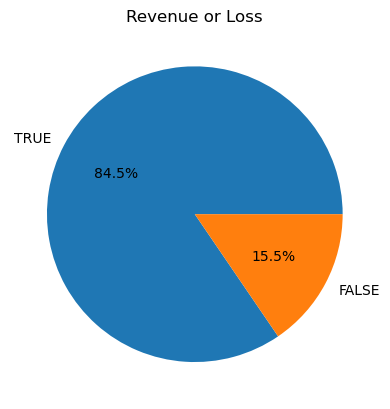

In [8]:
classes_count = df["Revenue"].value_counts()
classes_count

plt.pie(classes_count , labels=["TRUE" , "FALSE"] , autopct="%1.1f%%")
plt.title("Revenue or Loss")

### Label and OneHot Encoding

In [9]:
from sklearn.preprocessing import LabelEncoder , OneHotEncoder

La = LabelEncoder()
df["Revenue"] = La.fit_transform(df["Revenue"])
df["Weekend"] = La.fit_transform(df["Weekend"])

In [10]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,0,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,0,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,0,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,0,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,1,0


In [11]:
cols = ["VisitorType" , "Month"]

ohe = OneHotEncoder(drop="first" , sparse_output=False , handle_unknown="ignore")

encoded = ohe.fit_transform(df[cols]) #return 2D array

encoded_df = pd.DataFrame(encoded , columns=ohe.get_feature_names_out(cols) , index=df.index)
df = pd.concat([df.drop(columns=cols) , encoded_df] , axis=1)


In [12]:
df.head()
df.describe()
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 27 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Administrative                 12330 non-null  int64  
 1   Administrative_Duration        12330 non-null  float64
 2   Informational                  12330 non-null  int64  
 3   Informational_Duration         12330 non-null  float64
 4   ProductRelated                 12330 non-null  int64  
 5   ProductRelated_Duration        12330 non-null  float64
 6   BounceRates                    12330 non-null  float64
 7   ExitRates                      12330 non-null  float64
 8   PageValues                     12330 non-null  float64
 9   SpecialDay                     12330 non-null  float64
 10  OperatingSystems               12330 non-null  int64  
 11  Browser                        12330 non-null  int64  
 12  Region                         12330 non-null 

Administrative                   0
Administrative_Duration          0
Informational                    0
Informational_Duration           0
ProductRelated                   0
ProductRelated_Duration          0
BounceRates                      0
ExitRates                        0
PageValues                       0
SpecialDay                       0
OperatingSystems                 0
Browser                          0
Region                           0
TrafficType                      0
Weekend                          0
Revenue                          0
VisitorType_Other                0
VisitorType_Returning_Visitor    0
Month_Dec                        0
Month_Feb                        0
Month_Jul                        0
Month_June                       0
Month_Mar                        0
Month_May                        0
Month_Nov                        0
Month_Oct                        0
Month_Sep                        0
dtype: int64

In [13]:
encoded_df.head()

,VisitorType_Other,VisitorType_Returning_Visitor,Month_Dec,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep
0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [14]:
encoded

array([[0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 1., 0., ..., 1., 0., 0.],
       [0., 1., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.]], shape=(12330, 11))

In [15]:
ohe.get_feature_names_out(cols)

array(['VisitorType_Other', 'VisitorType_Returning_Visitor', 'Month_Dec',
       'Month_Feb', 'Month_Jul', 'Month_June', 'Month_Mar', 'Month_May',
       'Month_Nov', 'Month_Oct', 'Month_Sep'], dtype=object)

In [ ]:
# X and y Split

X = df.drop("Revenue" , axis=1)
y = df["Revenue"]


In [22]:
X.head()
y.head()

0    0
1    0
2    0
3    0
4    0
Name: Revenue, dtype: int64

In [23]:
# Train Test Split 

X_train , X_test , y_train , y_test = train_test_split(
    X , y ,
    test_size=0.2 ,
    random_state=42
)

In [25]:
X_train.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,VisitorType_Returning_Visitor,Month_Dec,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep
1785,0,0.0,0,0.0,7,95.000000,0.014286,0.061905,0.000000,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
10407,2,14.0,0,0.0,81,1441.910588,0.002469,0.013933,2.769599,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
286,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
6520,5,49.2,4,379.0,5,74.600000,0.000000,0.018182,8.326728,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
12251,0,0.0,1,5.0,9,279.000000,0.040000,0.041667,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [26]:
from sklearn.preprocessing import StandardScaler

scalar = StandardScaler()

X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)

In [28]:
X_test_scaled
X_train_scaled

array([[-0.69846932, -0.45693682, -0.39741233, ..., -0.56970187,
        -0.21607708, -0.19293516],
       [-0.09184802, -0.3780645 , -0.39741233, ...,  1.75530404,
        -0.21607708, -0.19293516],
       [-0.69846932, -0.45693682, -0.39741233, ..., -0.56970187,
        -0.21607708, -0.19293516],
       ...,
       [-0.69846932, -0.45693682, -0.39741233, ..., -0.56970187,
        -0.21607708, -0.19293516],
       [-0.69846932, -0.45693682, -0.39741233, ..., -0.56970187,
        -0.21607708, -0.19293516],
       [ 1.42470521,  0.32136402, -0.39741233, ..., -0.56970187,
         4.62797816, -0.19293516]], shape=(9864, 26))

### Train and Evalute the model 


In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score , accuracy_score , confusion_matrix , recall_score , f1_score

log_model = LogisticRegression()
log_model.fit(X_train_scaled , y_train)

y_pred = log_model.predict(X_test_scaled)
print("Logistic Regression")
print("Precision :" , precision_score(y_test , y_pred))
print("Recall :" , recall_score(y_test , y_pred))
print("f1 score :" , f1_score(y_test , y_pred))
print("Confusion Matrix :" , confusion_matrix(y_test , y_pred))
print("Accuracy :" , accuracy_score(y_test , y_pred))


Logistic Regression
Precision : 0.7552083333333334
Recall : 0.35279805352798055
f1 score : 0.48092868988391374
Confusion Matrix : [[2008   47]
 [ 266  145]]
Accuracy : 0.8730738037307381


In [31]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier()
knn_model.fit(X_train_scaled , y_train)





,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [32]:
y_pred = knn_model.predict(X_test_scaled)
print("KNN")
print("Precision :" , precision_score(y_test , y_pred))
print("Recall :" , recall_score(y_test , y_pred))
print("f1 score :" , f1_score(y_test , y_pred))
print("Confusion Matrix :" , confusion_matrix(y_test , y_pred))
print("Accuracy :" , accuracy_score(y_test , y_pred))

KNN
Precision : 0.7120418848167539
Recall : 0.3309002433090024
f1 score : 0.45182724252491696
Confusion Matrix : [[2000   55]
 [ 275  136]]
Accuracy : 0.8661800486618005


In [34]:
# Decision Tree Model - Purning

from sklearn.tree import DecisionTreeClassifier

dec_model = DecisionTreeClassifier()
dec_model.fit(X_train_scaled , y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [35]:
y_pred = dec_model.predict(X_test_scaled)
print("Decision Tree :")
print("Precision :" , precision_score(y_test , y_pred))
print("Recall :" , recall_score(y_test , y_pred))
print("f1 score :" , f1_score(y_test , y_pred))
print("Confusion Matrix :" , confusion_matrix(y_test , y_pred))
print("Accuracy :" , accuracy_score(y_test , y_pred))

Decision Tree :
Precision : 0.5735294117647058
Recall : 0.5693430656934306
f1 score : 0.5714285714285714
Confusion Matrix : [[1881  174]
 [ 177  234]]
Accuracy : 0.8576642335766423


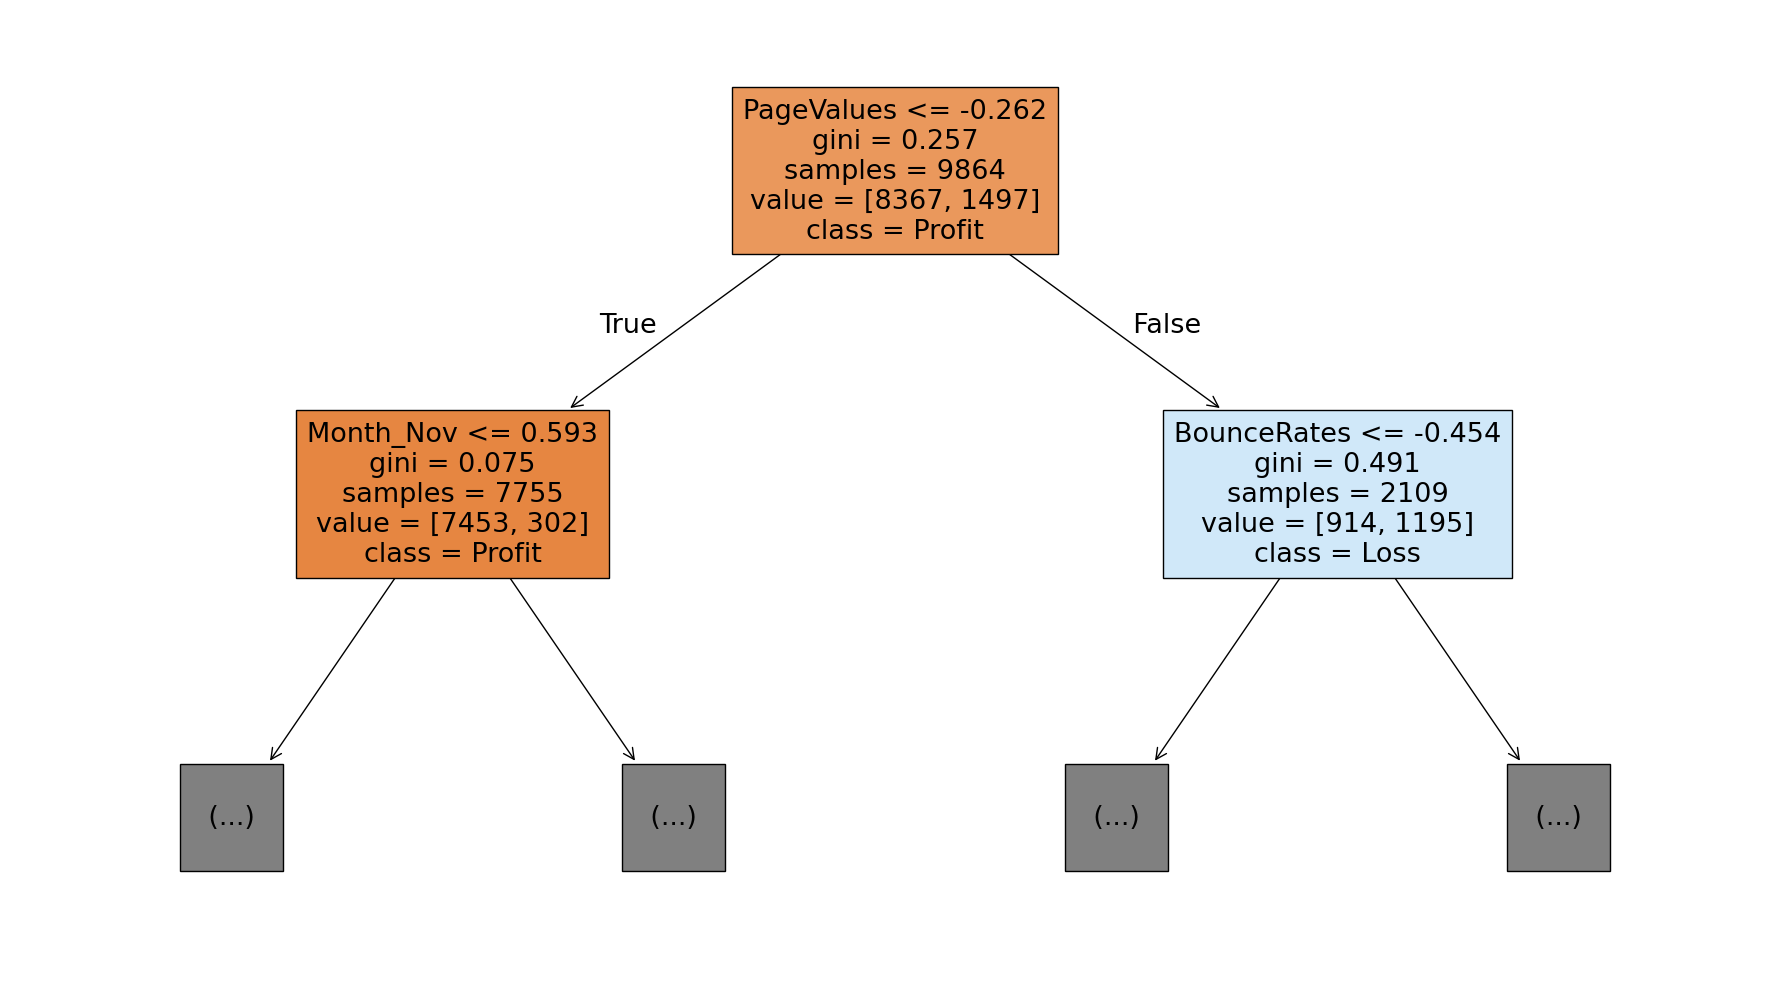

In [37]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18 , 10))
plot_tree(
    dec_model ,
    feature_names=X.columns,
    class_names=["Profit" , "Loss"],
    filled=True,
    max_depth=1
)
plt.tight_layout()
plt.show()

In [38]:
# Decision Tree with Pre-Purning 

max_depth = [2,3,4,5,6,7,8,9,10]

for depth in max_depth:
    dec_model = DecisionTreeClassifier()
    dec_model.fit(X_train_scaled , y_train)

    acc = dec_model.score(X_test_scaled , y_test)
    print(f"for depth = {depth} , accuracy = {acc}")

for depth = 2 , accuracy = 0.8617193836171938
for depth = 3 , accuracy = 0.8596918085969181
for depth = 4 , accuracy = 0.8576642335766423
for depth = 5 , accuracy = 0.8580697485806975
for depth = 6 , accuracy = 0.856853203568532
for depth = 7 , accuracy = 0.8560421735604218
for depth = 8 , accuracy = 0.8540145985401459
for depth = 9 , accuracy = 0.8600973236009732
for depth = 10 , accuracy = 0.8592862935928629


In [39]:
# Decision Tree with Post purning 

full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train_scaled , y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [40]:
# Cost Complexity 

path = full_tree.cost_complexity_pruning_path(X_train_scaled , y_train)
ccp_alphas = path.ccp_alphas
print(ccp_alphas)

[0.00000000e+00 5.04680245e-05 6.58528639e-05 6.60140704e-05
 6.66941115e-05 6.67684446e-05 6.67907066e-05 6.69232278e-05
 6.70578197e-05 6.72124316e-05 6.73418418e-05 6.74631737e-05
 7.85090604e-05 7.89964294e-05 8.11030008e-05 8.68960723e-05
 8.68960723e-05 8.72536693e-05 8.87064071e-05 8.87064071e-05
 8.87064071e-05 8.87064071e-05 8.96812028e-05 9.01144453e-05
 9.01144453e-05 9.01144453e-05 9.01144453e-05 9.07982102e-05
 9.21625009e-05 9.32684509e-05 9.33751654e-05 9.35803856e-05
 9.35803856e-05 9.35803856e-05 9.35803856e-05 9.41374117e-05
 9.41374117e-05 9.41374117e-05 9.44980879e-05 9.46201676e-05
 9.50425791e-05 9.50425791e-05 9.50425791e-05 9.54152951e-05
 9.55182436e-05 9.57465982e-05 9.58810312e-05 9.60178457e-05
 9.60430273e-05 9.61798407e-05 9.63098135e-05 9.67483080e-05
 9.67706260e-05 9.69709792e-05 9.72408428e-05 9.73236010e-05
 9.74795683e-05 9.74795683e-05 9.78829320e-05 9.79633172e-05
 9.79994593e-05 9.81084687e-05 9.81084687e-05 9.82594048e-05
 9.83066676e-05 9.835251

In [43]:
# train our model for all alphas
# alpha -> is used to control the trade off between trees size and its ability to accurately predict data 


trees = []

for alpha in ccp_alphas:
    dec_model1 = DecisionTreeClassifier(random_state=42 , ccp_alpha=alpha)
    dec_model1.fit(X_train_scaled , y_train)
    trees.append((dec_model1 , alpha))




In [42]:
trees

[(DecisionTreeClassifier(ccp_alpha=np.float64(0.0), random_state=42),
  np.float64(0.0)),
 (DecisionTreeClassifier(ccp_alpha=np.float64(5.04680245221474e-05),
                         random_state=42),
  np.float64(5.04680245221474e-05)),
 (DecisionTreeClassifier(ccp_alpha=np.float64(6.585286390639184e-05),
                         random_state=42),
  np.float64(6.585286390639184e-05)),
 (DecisionTreeClassifier(ccp_alpha=np.float64(6.601407042758262e-05),
                         random_state=42),
  np.float64(6.601407042758262e-05)),
 (DecisionTreeClassifier(ccp_alpha=np.float64(6.66941115291103e-05),
                         random_state=42),
  np.float64(6.66941115291103e-05)),
 (DecisionTreeClassifier(ccp_alpha=np.float64(6.67684446389078e-05),
                         random_state=42),
  np.float64(6.67684446389078e-05)),
 (DecisionTreeClassifier(ccp_alpha=np.float64(6.679070655025995e-05),
                         random_state=42),
  np.float64(6.679070655025995e-05)),
 (Decision

In [44]:
best_acc = 0
best_alpha = 0

for dec_model1 , alpha in trees:
    curr_acc = dec_model1.score(X_test_scaled , y_test)

    if(curr_acc > best_acc):
        best_acc = curr_acc
        best_alpha = alpha
    

In [46]:
best_alpha
best_acc

0.8961881589618816

In [47]:
best_model = DecisionTreeClassifier(ccp_alpha=best_alpha , max_depth=1)
best_model.fit(X_train_scaled , y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


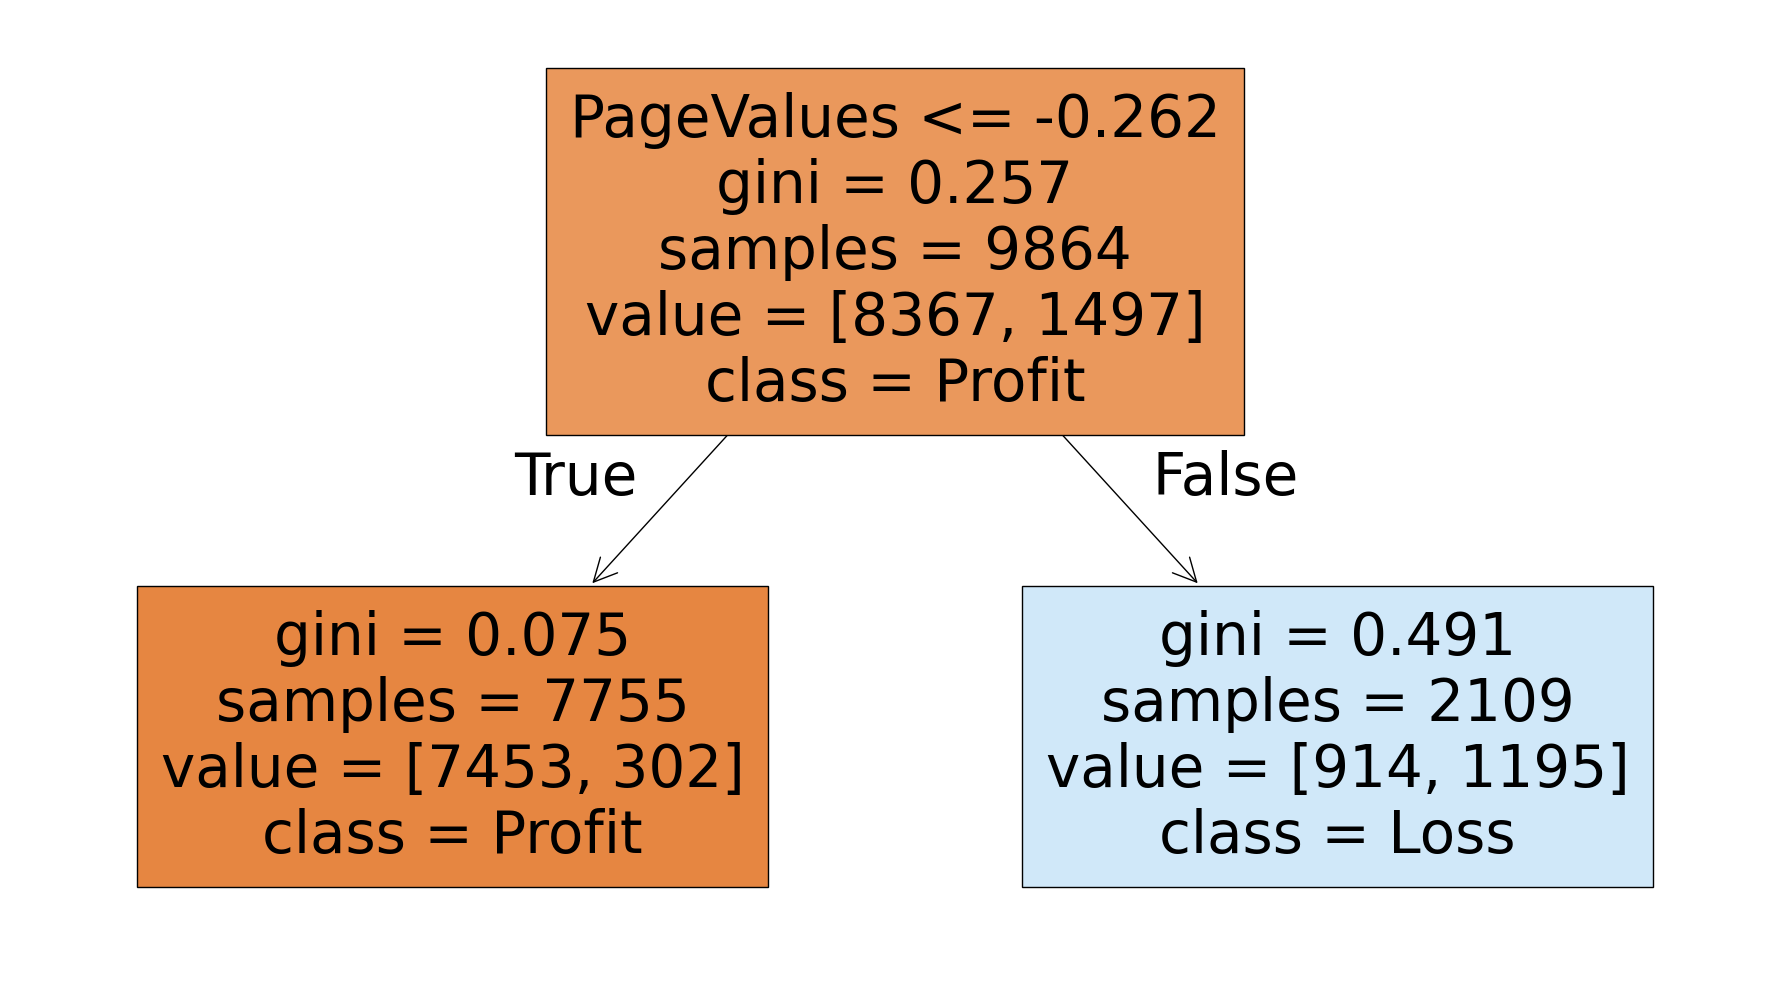

In [48]:
plt.figure(figsize=(18 , 10))
plot_tree(
    best_model ,
    feature_names=X.columns,
    class_names=["Profit" , "Loss"],
    filled=True
)

plt.tight_layout()
plt.show()

In [49]:
print("Best Score ->" , best_model.score(X_test_scaled , y_test))

Best Score -> 0.8722627737226277
